In [13]:
import os
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 20000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# Load df_all_map_meta from file
base_dir = 'map/Yamal-Nenets'

df_all_map_meta = pd.read_csv(os.path.join(base_dir, 'map_all_metadata.csv'))

def ensure_dict(x):
    # your logic here, e.g.:
    import ast
    if isinstance(x, dict):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return {}
    
df_all_map_meta['corners'] = df_all_map_meta['corners'].apply(ensure_dict)

# Check file
print(f'# of maps: {len(df_all_map_meta)}')
print(df_all_map_meta.head(100))

# of maps: 880
                                                                                                                                  map_file                                                                 gif_file  year scale        index             datum            projection                                                                                                              projection_params  image_width  image_height                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    control_points                         

In [ ]:
# translate_to_wgs84

from pyproj import Transformer

def reproject_points_to_wgs84(points, from_epsg=4284, to_epsg=4326):
    transformer = Transformer.from_crs(f"EPSG:{from_epsg}", f"EPSG:{to_epsg}", always_xy=True)
    new_points = {}
    for k, v in points.items():
        try:
            lon, lat = transformer.transform(v['lon'], v['lat'])
            new_points[k] = {'lat': lat, 'lon': lon, 'x': v.get('x'), 'y': v.get('y')}
        except Exception as e:
            print(f"⚠️ Failed to reproject point {k}: {e}")
    return new_points



In [ ]:
# Iterate through each map metadata, in the datum column, there are two types: "WGS 84" and "Pulkovo 1942 (2)". We need to translate control points and corners to WGS 84 if they are in Pulkovo 1942 (2).
for i, row in df_all_map_meta.iterrows():
    if row['datum'] == 'Pulkovo 1942 (2)':
        # Translate control points
        if isinstance(row['control_points'], str):
            control_points = eval(row['control_points'])
            # Assuming a function translate_to_wgs84 exists
            translated_control_points = reproject_points_to_wgs84(control_points)
            df_all_map_meta.at[i, 'control_points'] = translated_control_points
        
        # Translate corners
        if isinstance(row['corners'], dict):
            corners = row['corners']
            # Assuming a function translate_to_wgs84 exists
            translated_corners = reproject_points_to_wgs84(corners)
            df_all_map_meta.at[i, 'corners'] = translated_corners


In [14]:
def get_map_bounds(corners):
    """Extract geographic extent from the corners dictionary."""
    try:
        lats = [v['lat'] for v in corners.values()]
        lons = [v['lon'] for v in corners.values()]
        return {
            'min_lat': min(lats),
            'max_lat': max(lats),
            'min_lon': min(lons),
            'max_lon': max(lons),
        }
    except Exception as e:
        print(f"Error computing bounds: {e}")
        return None

def filter_maps_by_bounding_box(df_all_map_meta, bounding_box, allow_partial_overlap=False):
    """
    Filters maps based on geographic bounding box.
    If allow_partial_overlap is False, maps must fully contain the bounding box.
    If True, maps that intersect with the bounding box in any way are included.
    """
    def is_full_containment(map_bounds, bbox):
        return (
            map_bounds['min_lat'] <= bbox['min_lat'] and
            map_bounds['max_lat'] >= bbox['max_lat'] and
            map_bounds['min_lon'] <= bbox['min_lon'] and
            map_bounds['max_lon'] >= bbox['max_lon']
        )

    def is_partial_overlap(map_bounds, bbox):
        return not (
            map_bounds['max_lat'] < bbox['min_lat'] or
            map_bounds['min_lat'] > bbox['max_lat'] or
            map_bounds['max_lon'] < bbox['min_lon'] or
            map_bounds['min_lon'] > bbox['max_lon']
        )

    filtered_rows = []
    for idx, row in df_all_map_meta.iterrows():
        corners = row.get('corners', {})
        if not corners or not isinstance(corners, dict) or len(corners) < 4:
            continue

        map_bounds = get_map_bounds(corners)
        if map_bounds is None:
            continue

        if allow_partial_overlap:
            if is_partial_overlap(map_bounds, bounding_box):
                filtered_rows.append(row)
        else:
            if is_full_containment(map_bounds, bounding_box):
                filtered_rows.append(row)

    return pd.DataFrame(filtered_rows).reset_index(drop=True)


In [15]:
# Upper-left corner: 67.703940, 70.896236
# Lower-right corner: 67.479662, 71.716828
# Define the bounding box

# 69.219736, 69.962104 (Top Left)
# 69.110052, 70.312855 (Bottom Right)

bounding_box = {
    "min_lat": 69.110052,
    "max_lat": 69.219736,
    "min_lon": 69.962104,
    "max_lon": 70.312855
}

df_filtered = filter_maps_by_bounding_box(df_all_map_meta, bounding_box, allow_partial_overlap=True)
print(f"Filtered maps that fully contain the bounding box: {len(df_filtered)}")
if not df_filtered.empty:
    print(df_filtered[['map_file', 'year', 'gif_path']].head())
else:
    print("No maps matched the bounding box criteria.")


Filtered maps that fully contain the bounding box: 8
                                                                                                                              map_file  year                                                                                                                             gif_path
0  map/Yamal-Nenets/yamalo-nenets-ao--ams--001m--(1957-1957)/maps/en--ams--001m--nr41-42--(1957)--N072-00_E060-00--N068-00_E072-00.map  1957  map/Yamal-Nenets/yamalo-nenets-ao--ams--001m--(1957-1957)/maps/en--ams--001m--nr41-42--(1957)--N072-00_E060-00--N068-00_E072-00.gif
1      map/Yamal-Nenets/yamalo-nenets-ao--onc--001m--(1973-1982)/maps/en--onc--001m--c04--(1982)--N072-00_E063-00--N064-00_E091-00.map  1982      map/Yamal-Nenets/yamalo-nenets-ao--onc--001m--(1973-1982)/maps/en--onc--001m--c04--(1982)--N072-00_E063-00--N064-00_E091-00.gif
2           map/Yamal-Nenets/nenets-ao--tpc--500k--(1982-1989)/maps/en--tpc--500k--c04-a--(1988)--N072-00_E063-00--N068-00_E0

In [16]:
print(df_filtered)

# Find out maps that have the 'year' column empty (NaN)
maps_with_empty_year = df_all_map_meta[df_all_map_meta['year'].isna()]
print(f"Maps with empty 'year' column: {len(maps_with_empty_year)}")
if not maps_with_empty_year.empty:
    print(maps_with_empty_year[['map_file']].head())

                                                                                                                              map_file                                                              gif_file  year scale      index             datum           projection                                                                                                             projection_params  image_width  image_height                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            control_points                                                           

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

def geo_to_pixel(lat, lon, corners):
    """Map (lat, lon) to (x, y) pixel using bilinear interpolation."""
    tl, tr, br, bl = corners[1], corners[2], corners[3], corners[4]

    lon_frac = (lon - tl['lon']) / (tr['lon'] - tl['lon'])
    lat_frac = (tl['lat'] - lat) / (tl['lat'] - bl['lat'])

    x = tl['x'] + lon_frac * (tr['x'] - tl['x'])
    y = tl['y'] + lat_frac * (bl['y'] - tl['y'])
    return int(round(x)), int(round(y))

def crop_image_by_geo_bbox(image_path, corners, bbox):
    """Crop an image using geographic bounding box."""
    im = Image.open(image_path)

    try:
        x_min, y_max = geo_to_pixel(bbox['max_lat'], bbox['min_lon'], corners)
        x_max, y_min = geo_to_pixel(bbox['min_lat'], bbox['max_lon'], corners)

        left, upper = min(x_min, x_max), min(y_min, y_max)
        right, lower = max(x_min, x_max), max(y_min, y_max)

        return im.crop((left, upper, right, lower))
    except Exception as e:
        print(f"Failed to crop {image_path}: {e}")
        return None

In [18]:
def display_cropped_maps(df_filtered, bounding_box, max_maps=12):
    """Crop and display all maps that intersect with the bounding box."""
    cropped_images = []

    for idx, row in df_filtered.iterrows():
        gif_path = row['gif_path']
        corners = row['corners']

        if not all(k in corners for k in [1, 2, 3, 4]):
            print(f"[SKIP] Incomplete corners for {gif_path}")
            continue

        cropped = crop_image_by_geo_bbox(gif_path, corners, bounding_box)
        if cropped:
            cropped_images.append((f"{row['index']} ({row['year']})", cropped))
        if len(cropped_images) >= max_maps:
            break

    # Plot the results
    num_images = len(cropped_images)
    cols = 3
    rows = (num_images + cols - 1) // cols
    plt.figure(figsize=(cols * 5, rows * 5))

    for i, (title, img) in enumerate(cropped_images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [19]:
print(df_filtered)

                                                                                                                              map_file                                                              gif_file  year scale      index             datum           projection                                                                                                             projection_params  image_width  image_height                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            control_points                                                           

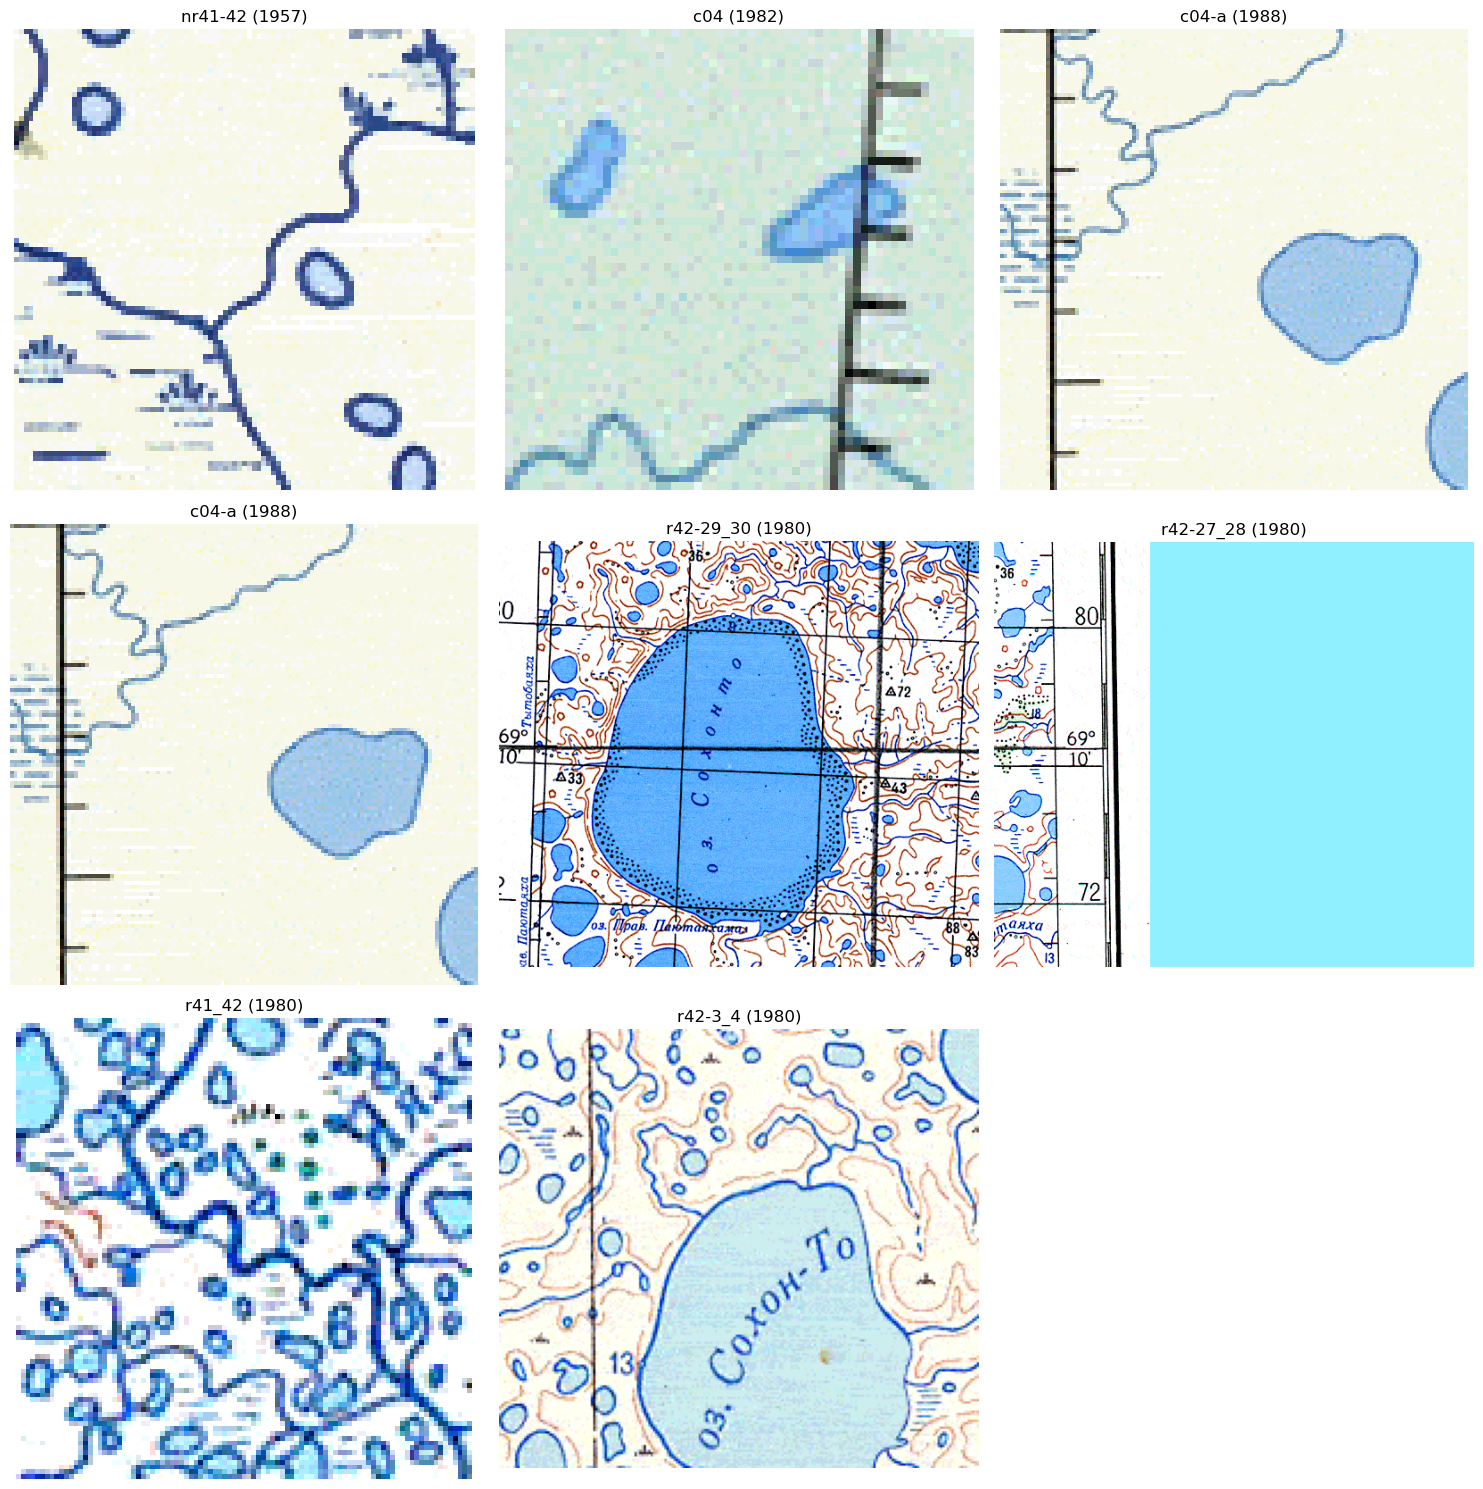

In [20]:
display_cropped_maps(df_filtered, bounding_box)